In [1]:
import VMBQC_functions
from VMBQC_functions import *

In [2]:
# Hyperparameters

samples=6000 # Total number of samples from MBQC-CQCA (includes the "shots" for each circuit with different byproducts)
target_samples = samples

k=0
qubits=6
depth=2
layers=depth

##  Learning models

In [3]:


dev = qml.device("default.qubit", wires=qubits,shots=samples)

@qml.qnode(dev)
def eqv_circ_st(params):  
    
    p=params[:int(len(params)/2)] # probabilities
    
    t=params[len(p):] # thetas

   
    vis_qubits = range(qubits)

    [qml.RX(np.pi/4,wires=q) for q in vis_qubits]
    
    num_edges = qubits - 1          # open boundary
    params_per_layer = 2 * qubits + num_edges
    
    for l in range(depth):
        offset = l * params_per_layer
    
        rz_offset  = offset
        zz_offset  = rz_offset + qubits
        rx_offset  = zz_offset + num_edges
    
        # RZ layer
        for q in range(qubits):
            qml.RZ(t[rz_offset + q], wires=q)
    
        # RZZ layer, open boundary
        for q in range(qubits - 1):
            qml.MultiRZ(t[zz_offset + q], wires=[q, q + 1])
    
        
    
        # RX layer
        for q in range(qubits):
            qml.RX(t[rx_offset + q], wires=q)


    return qml.sample() 

In [4]:
def sample_circ(par):
    
    binary_array = np.array(eqv_circ_st(par))
    # binary_array = np.array(target_emodel(par))
    powers_of_two = 2 ** np.arange(binary_array.shape[1])[::-1]
    decimal_array = np.sum(binary_array * powers_of_two, axis=1)
    decimal_list = decimal_array.tolist()
    
    return decimal_list



# Testing the analytical result in vmbqc paper

Keep the $\theta$s fixed and see the effect of the $p_c$s

In [5]:
t2=np.random.uniform(np.pi/4,np.pi/4,depth*(3*qubits-1))
# t2=global_bitflip_thetas(N=qubits,D=depth)

In [6]:
p2=np.ones((depth*(3*qubits-1)))
p2

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1.], requires_grad=True)

In [7]:
init_para= np.concatenate([inv_sigmoid(p2),t2], requires_grad=True)
eqv_circ_st(init_para)

/home/arun/.local/lib/python3.10/site-packages/pennylane/numpy/tensor.py:152: RuntimeWarning: divide by zero encountered in divide
  res = super().__array_ufunc__(ufunc, method, *args, **kwargs)


array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 1],
       [0, 0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0, 0],
       [1, 1, 0, 0, 0, 0],
       [1, 1, 1, 0, 1, 0]])

0.10338282585144043 sec


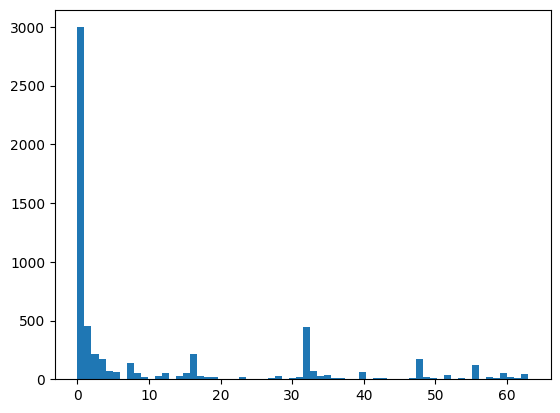

In [8]:
def target_circuit(init_para):  
    
    return sample_circ(init_para)



init_para= np.concatenate([inv_sigmoid(p2),t2], requires_grad=True)
s=time.time()
f_s_t=plt.hist(target_circuit(init_para),bins=2**qubits)
e=time.time()
print(e-s,'sec')

In [9]:
init_para

tensor([       inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf, 0.78539816,
        0.78539816, 0.78539816, 0.78539816, 0.78539816, 0.78539816,
        0.78539816, 0.78539816, 0.78539816, 0.78539816, 0.78539816,
        0.78539816, 0.78539816, 0.78539816, 0.78539816, 0.78539816,
        0.78539816, 0.78539816, 0.78539816, 0.78539816, 0.78539816,
        0.78539816, 0.78539816, 0.78539816, 0.78539816, 0.78539816,
        0.78539816, 0.78539816, 0.78539816, 0.78539816, 0.78539816,
        0.78539816, 0.78539816, 0.78539816], requires_grad=True)

In [11]:
pg = np.loadtxt('peaked_dist')#np.loadtxt('biased_product_distribution')
# # sum(pg)
# pg[:]=0
# # pg[0]=1/2
# pg[15]=1

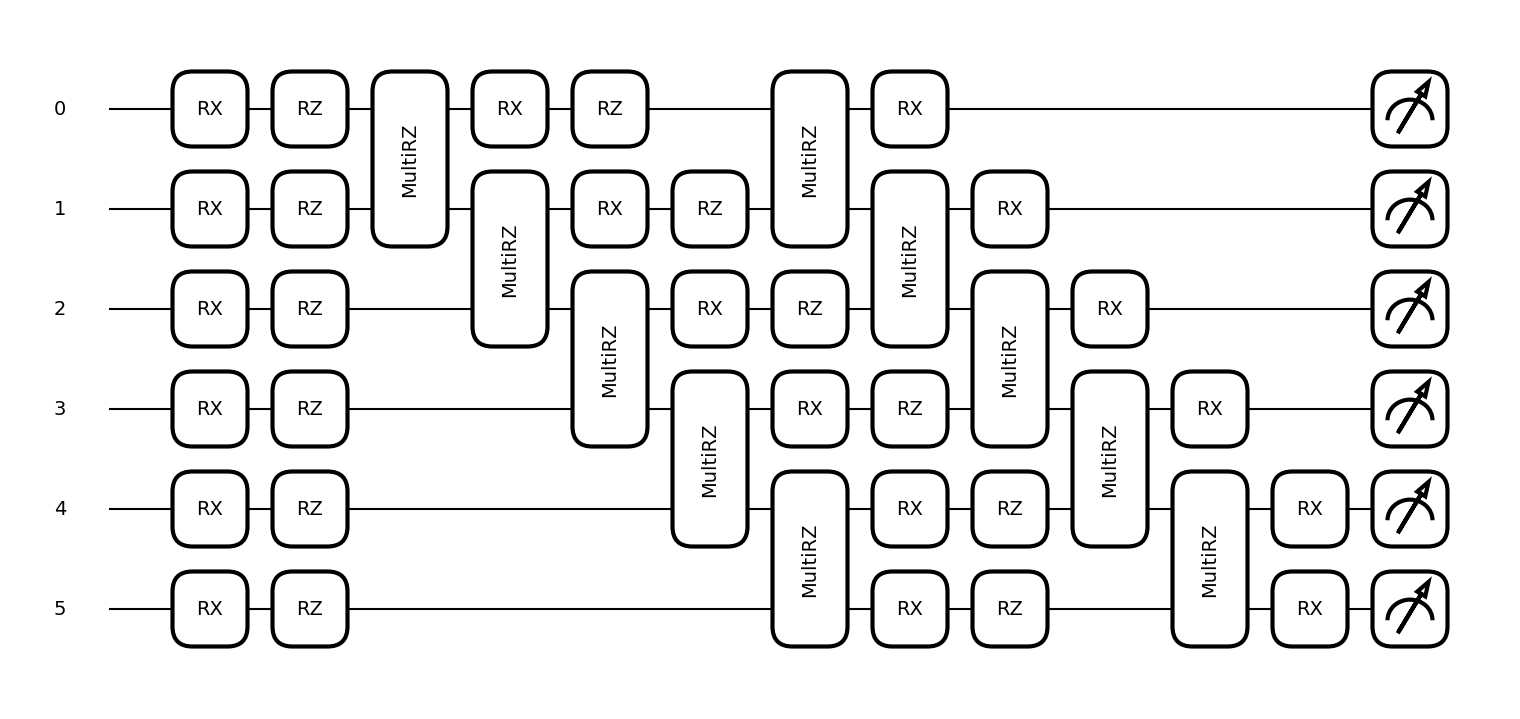

In [12]:
def plot_cqca_circuit(qubits=4):

    
    
    
    
    fig, ax = qml.draw_mpl(eqv_circ_st, expansion_strategy="device")(init_para)
    plt.show()

# Example:
plot_cqca_circuit(qubits=5)


In [13]:
# sampling from target distribution e.g. mixed gaussian
def sample_target_function():
    x=range(2**qubits)
    ret = np.random.choice(x,samples,p=pg)
    return ret.copy()

0.0704190731048584 sec


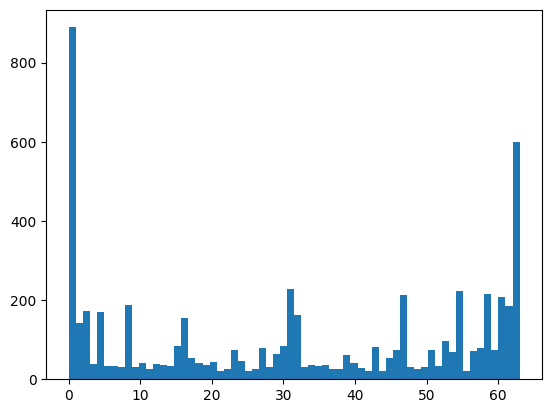

In [14]:
s=time.time()
opt_hist=plt.hist(sample_target_function(),bins=2**qubits)
e=time.time()
print(e-s,'sec')

In [15]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [16]:
# kernel function to calculate distance between two sample data points

def kernel_exp_torch(s1,s2):
    s1t = torch.tensor(s1, dtype = torch.float64).to(DEVICE)
    s2t = torch.tensor(s2, dtype = torch.float64).to(DEVICE)
    d1 = s1t.size(-1)
    d2 = s2t.size(-1)
    s1t = s1t.reshape([1,-1,1])
    s2t = s2t.reshape([1,-1,1])
    
    diffsquared = (torch.cdist(s1t,s2t,p=2.0).to(DEVICE))**2

    sigma_list=[2.5]
    exp = 0.0
    for sigma in sigma_list:
        expMatrix = torch.exp(diffsquared/(-2.0*sigma)).to(DEVICE)
        expMatrix = expMatrix/(len(sigma_list)*d1*d2)
        exp = exp + torch.sum(expMatrix).to(DEVICE)
        
    return exp

In [17]:
def mmd_loss(params):
    
    s2=sample_target_function()
    s1=sample_circ(params)
    res=kernel_exp_torch(s1,s1)-2*kernel_exp_torch(s1,s2)+kernel_exp_torch(s2,s2)
    return res.detach().cpu().numpy()


In [18]:
# Gradient for correction probabilities stated in eq. 17 of: https://arxiv.org/pdf/2310.13524.pdf

def mmd_grad_p_new(params):
    p=params[:qubits*depth]
    thetas=params[len(p):]
    grad = torch.zeros(len(p)).to(DEVICE)
    
    
    
    sample_targ=sample_target_function()
    
    for i in range(len(p)):
        
        sample_y = sample_circ(params) ###############  eqv_circ_st(params)
        
        a=p[i].copy()
        inner_derivative = (sigmoid(torch.tensor(a))**2)*torch.exp(-torch.tensor(a))
        
        p[i]=torch.tensor(100.0).numpy()
        
        sample_x_1 = sample_circ(params) ###############  eqv_circ_st(params)
       
        
        p[i]=torch.tensor(-100.0).numpy()
        
        sample_x_0 = sample_circ(params) ###############  eqv_circ_st(params)
        
        
        grad[i]=2*(kernel_exp_torch(sample_y,sample_x_1)-kernel_exp_torch(sample_y,sample_x_0)) - 2*(kernel_exp_torch(sample_targ,sample_x_1)-kernel_exp_torch(sample_targ,sample_x_0))
        grad[i]= grad[i]*inner_derivative
        p[i]=a
        #if i == 0:
        #    print(params[:int(len(params)/2)])

        
    return grad


def mmd_grad_1layer_1p_new(params):
    p=params[:qubits*depth]
    thetas=params[len(p):]
    # grad = torch.zeros(len(p)).to(DEVICE)
    grad_1 = torch.zeros(len(p)).to(DEVICE)

    d=1 # The layer we want to train
    
    for i in range(d): # as you have only N prob that repeats across the first layer
            
        sample_targ=sample_target_function()
        sample_y = sample_circ(params) ###############  eqv_circ_st(params)
        
        a=p[i].copy()
        inner_derivative = (sigmoid(torch.tensor(a))**2)*torch.exp(-torch.tensor(a))
        
        p[i]=torch.tensor(100.0).numpy()
        
        sample_x_1 = sample_circ(params) ###############  eqv_circ_st(params)
       
        
        p[i]=torch.tensor(-100.0).numpy()
        
        sample_x_0 = sample_circ(params) ###############  eqv_circ_st(params)
        
        
        grad_1[i]=2*(kernel_exp_torch(sample_y,sample_x_1)-kernel_exp_torch(sample_y,sample_x_0)) - 2*(kernel_exp_torch(sample_targ,sample_x_1)-kernel_exp_torch(sample_targ,sample_x_0))
        grad_1[i]= grad_1[i]*inner_derivative
        p[i]=a
        
    grad_1[:2]=grad_1[0] ## important step about where to put the byproducts

        
    return grad_1
    
    
# Gradient for variational parameters \thetas stated in eq. 16 of: https://arxiv.org/pdf/2310.13524.pdf
    
def mmd_grad_theta(params):
    p=params[:qubits*depth]
    thetas=params[len(p):]
    prob = sample_circ(params)
    grad = torch.zeros(len(thetas)).to(DEVICE)
    
    for i in range(len(thetas)):
        # pi/2 phase
        thetas[i] += np.pi/2.
        prob_pos = sample_circ(params) # p_{theta}^{+}
        # -pi/2 phase
        thetas[i] -= np.pi
        prob_neg = sample_circ(params) # p_{theta}^{-}
        
        t1=kernel_exp_torch(prob, prob_pos)
        
        t2=kernel_exp_torch(prob, prob_neg)

        t3=kernel_exp_torch(sample_target_function(), prob_pos)
        
        t4=kernel_exp_torch(sample_target_function(), prob_neg)

        
        grad_pos = t1 - t2
        grad_neg = t3 - t4
        grad[i] = (grad_pos - grad_neg).detach().cpu()
        
        thetas[i] += np.pi/2.0 #reset to original value
        
    return grad


# combined gradient of both sets of parameters

def mmd_grad(params):
    
    grad=torch.cat((mmd_grad_1layer_1p_new(params),mmd_grad_theta(params)))
    return grad

In [19]:
'''
import torch
import gc
for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):
            print(obj.shape, type(obj), obj.size(), obj.device)
    except:
        pass
'''

"\nimport torch\nimport gc\nfor obj in gc.get_objects():\n    try:\n        if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):\n            print(obj.shape, type(obj), obj.size(), obj.device)\n    except:\n        pass\n"

In [20]:
#torch.cuda.empty_cache()

In [21]:
#import gc

#gc.collect()
#torch.cuda.empty_cache()


In [22]:
# algorithm for gradient descent copied from : https://docs.pennylane.ai/en/stable/code/api/pennylane.GradientDescentOptimizer.html

# We rewrote the algorithm with our approximate gradient calculated from samples instead of using the in-built exact gradient 

class GradientDescentOptimizer_mmd_2:  
    def __init__(self, stepsize): # if some value is given here itself then it will become a by default value
        self.stepsize = stepsize

    def step_and_cost(self, objective_fn, *args, grad_fn=None, **kwargs):
        
        g, forward = self.compute_grad(objective_fn, args, kwargs, grad_fn=grad_fn)
        new_args = self.apply_grad(g, args)

        if forward is None:
            forward = objective_fn(*args, **kwargs)

        # unwrap from list if one argument, cleaner return
        if len(new_args) == 1:
            return new_args[0], forward
        return new_args, forward


    def step(self, objective_fn, *args, train, grad_fn=None, **kwargs):
        
        p_len=int(len(args[0])/2)
        if train=='p':
            arg1=args[0][:int(len(args[0])/2)]
        else:
            arg1=args[0][int(len(args[0])/2):]
        
        g= self.compute_grad(objective_fn, args, kwargs, grad_fn=grad_fn)
        new_args = self.apply_grad(g, arg1,args,train)

        # unwrap from list if one argument, cleaner return
        if len(new_args) == 1:
            return new_args[0]

        return new_args

    @staticmethod
    def compute_grad(objective_fn, args, kwargs, grad_fn=None):
       
        
        grad = mmd_grad(*args).detach().cpu().numpy()
        

        num_trainable_args = sum(getattr(arg, "requires_grad", False) for arg in args)
        grad = (grad,) if num_trainable_args == 1 else grad
        #print('grads--',grad[0])
        return grad


    def apply_grad(self, grad, arg1,args,train):
        
        #print('arg1--',arg1)#################
        args_new = list(arg1)
        
        if train=='p':

            trained_index = 0
            for index, arg in enumerate(arg1):

                if getattr(arg, "requires_grad", False):
                    args_new[index] = arg - self.stepsize * grad[0][trained_index]

                    trained_index += 1
        else:
            trained_index = p_len ########## need to be generalized
            for index, arg in enumerate(arg1):
                if getattr(arg, "requires_grad", False):
                    args_new[index] = arg - self.stepsize * grad[0][trained_index]

                    trained_index += 1
            
        
        #print('new args-->',args_new[0])#############
        
        if train=='p':
            return np.concatenate([args_new,args[0][len(args_new):]])
        else:
            return np.concatenate([args[0][:len(args_new)],args_new]) # here we can do this only because the they have same size
        

In [23]:
# We use parts the above above algorithm to finally use the Adagrad optimization algorithm below to update our tunable parameters

from pennylane.numpy import sqrt
class AdagradOptimizer_mmd_2(GradientDescentOptimizer_mmd_2):
    

    def __init__(self, stepsize=0.01, eps=1e-8):
        super().__init__(stepsize)
        self.eps = eps
        self.accumulation = None

    def apply_grad(self, grad, arg1, args, train):
        
        p_len=int(len(args[0])/2)
        args_new = list(arg1)

        if self.accumulation is None:
            self.accumulation = [0.0] * len(arg1)
            
        if train=='p':

            trained_index = 0
            for index, arg in enumerate(arg1):
                if getattr(arg, "requires_grad", False):
                    

                    self._update_accumulation(index, grad[0][trained_index])

                    coeff = self.stepsize / sqrt(self.accumulation[index] + self.eps)
                    args_new[index] = arg - coeff * grad[0][trained_index]

                    trained_index += 1
                    
        else:
            
            trained_index = p_len # need to be generalized
            
            for index, arg in enumerate(arg1):
                if getattr(arg, "requires_grad", False):
                    

                    self._update_accumulation(index, grad[0][trained_index])

                    coeff = self.stepsize / sqrt(self.accumulation[index] + self.eps)
                    args_new[index] = arg - coeff * grad[0][trained_index]

                    trained_index += 1
            
            

        if train=='p':
            return np.concatenate([args_new,args[0][len(args_new):]])
        else:
            return np.concatenate([args[0][:len(args_new)],args_new])


    def _update_accumulation(self, index, grad):
        
        self.accumulation[index] = self.accumulation[index] + grad**2

    def reset(self):
        
        self.accumulation = None

In [24]:
def cost(par):

    c=mmd_loss(par) 
    return c

In [25]:
# k=range(1)
# p2=np.ones((qubits*depth))
# p2[k]=np.random.uniform(1,1,1)
# t2=np.array([0.24016428, -1.16093848, -0.83412335, -0.5686455 ,  0.20066078,
#         -0.52270133, -0.39153164, -0.24378813, -0.22825565, -0.48595027,
#         -1.09854353, -0.1051636 , -0.28425527, -1.04837615, -0.84115078]) #np.random.uniform(np.pi/4,np.pi/4,qubits*depth)
# init_para=np.concatenate([inv_sigmoid(p2),t2], requires_grad=True)

# cost(init_para)

In [26]:
runs_2=20
iterations=299  # next time if run the same experiment for more agents then iterations=199


## seeding 
import random
import os

# Set seed for reproducibility (before any random ops)
seed = 42
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
####### end of seeding


# k=range(qubits)
cost_arr=[]
params_arr=[]
for r in range(runs_2):
    # opt1 = AdagradOptimizer_mmd_2(stepsize=0.2)
    opt2 = AdagradOptimizer_mmd_2(stepsize=0.5)
    
   
    k=range(1)
    p2=np.ones((depth*(3*qubits-1)))
    p2[k]=np.random.uniform(1,1,1)
    t2=np.random.uniform(0,1,depth*(3*qubits-1))
    init_p=np.concatenate([inv_sigmoid(p2),t2], requires_grad=True)
    params=init_p
    
    cost_arr.append(cost(init_p))
    params_arr.append(init_p)
    

    current_cost=[]
    
    for i in range(iterations):


        start=time.time()
        # params = opt1.step(cost, params,train='p')
        params = opt2.step(cost, params,train='t')
        end=time.time()
        current_cost.append(cost(params))
        cost_arr.append(current_cost[i])
        

        params_arr.append(params)
        #params_arr_tot_2.append(params)

        if i % 1 == 0:
            print(f"Cost at step {i}:", current_cost[i],f'of run:{r}')

            
            print('time taken-->',(end-start)/60,'min')

    
    

/home/arun/.local/lib/python3.10/site-packages/pennylane/numpy/tensor.py:152: RuntimeWarning: divide by zero encountered in divide
  res = super().__array_ufunc__(ufunc, method, *args, **kwargs)


Cost at step 0: 0.09891996668865644 of run:0
time taken--> 0.031473032633463544 min
Cost at step 1: 0.08808630532027854 of run:0
time taken--> 0.03120098908742269 min
Cost at step 2: 0.07232555549733437 of run:0
time taken--> 0.031156651178995767 min
Cost at step 3: 0.058463189252578915 of run:0
time taken--> 0.03124427398045858 min
Cost at step 4: 0.026897580238576316 of run:0
time taken--> 0.031210768222808837 min
Cost at step 5: 0.02150875526748272 of run:0
time taken--> 0.031246538956960043 min
Cost at step 6: 0.01714998737223443 of run:0
time taken--> 0.031283040841420494 min
Cost at step 7: 0.015178917775697395 of run:0
time taken--> 0.031268858909606935 min
Cost at step 8: 0.01610879380891042 of run:0
time taken--> 0.03126635551452637 min
Cost at step 9: 0.01691153138133042 of run:0
time taken--> 0.031230135758717855 min
Cost at step 10: 0.01615750396493712 of run:0
time taken--> 0.03123116890589396 min
Cost at step 11: 0.015082004132377397 of run:0
time taken--> 0.0312643051147

In [ ]:
np.sqrt(6)

In [1056]:
(params_arr[44][:])

tensor([        inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf, -0.48816998,
         1.08262635,  1.08262635,  1.08262635,  1.08262635,  1.08262635,
         1.08262635,  1.08262635,  1.08262635,  1.08262635,  1.08262635,
         1.08262635,  1.08262635,  1.08262635,  1.08262635,  1.08262635,
         1.08262635,  1.08262635,  1.08262635,  1.08262635,  1.08262635,
         1.08262635,  1.08262635,  1.08262635], requires_grad=True)

In [29]:
min(cost_arr)

array(0.00104643)

In [364]:
cost_arr.index(min(cost_arr))

140

In [366]:
(params_arr[cost_arr.index(min(cost_arr))])

tensor([        inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,  4.43007751,  1.42793947,  1.0510125 ,  0.35805513,
         0.11403998, -0.65667211,  1.92109623,  1.26985808,  1.84833773,
         0.6015764 ,  4.37795308,  1.34434184, -0.94448819,  1.13635919,
        -0.21051629,  1.73756326,  0.11714134,  1.21032005,  0.5986437 ,
         1.29499078,  1.03008697,  0.19308108,  2.19829635,  1.80172225,
         2.04246916,  1.1663799 ,  1.06218809,  1.26204588, -0.74631018,
         0.16230735, -1.22469924,  1.36658601,  1.3

In [313]:

mmd_loss(init_para)

array(0.02334119)

In [27]:
np.savetxt('models/class_1_peaked_loss_unit_model', cost_arr)

In [28]:
np.savetxt('models/class_1_peaked_par_unit_model', params_arr)